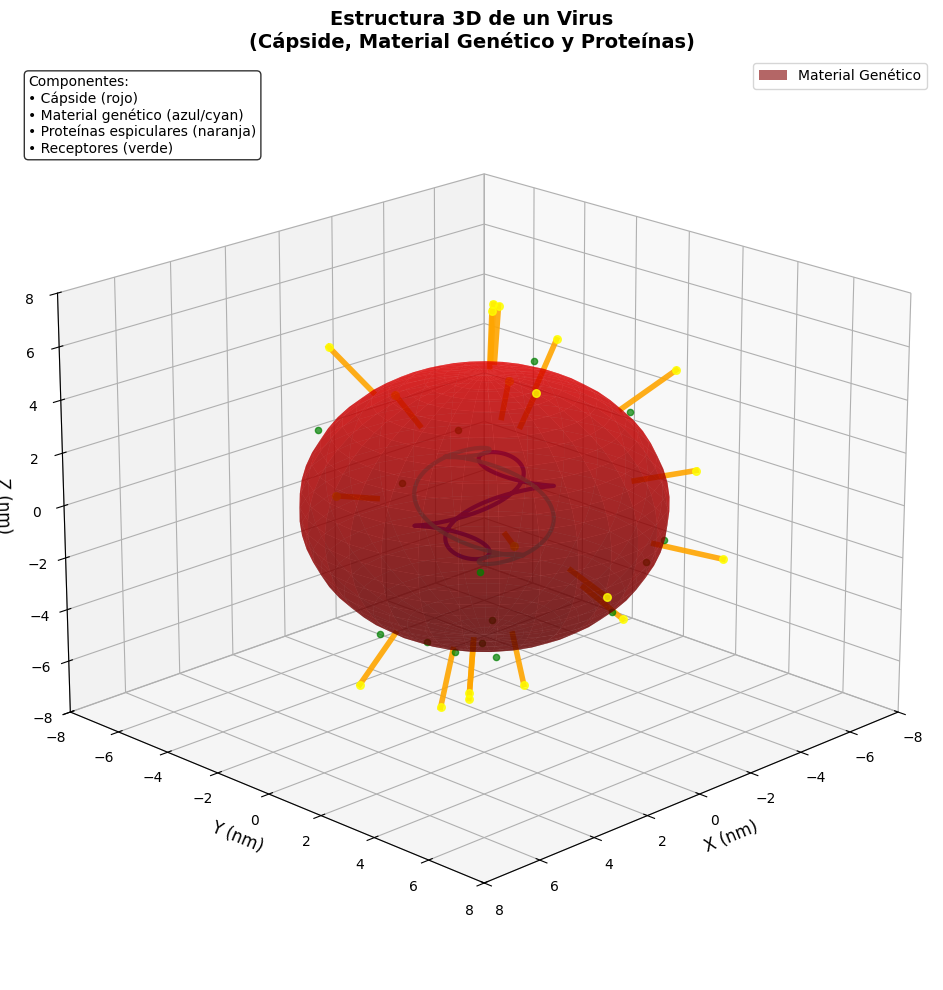

🦠 MODELO DE VIRUS 3D GENERADO
• Radio de la cápside: 5 nm
• Número de proteínas espiculares: 20
• Número de receptores: 15
• Altura de proteínas espiculares: 2 nm

Componentes visualizados:
• Cápside viral (estructura principal)
• Material genético interno (ARN/ADN)
• Proteínas espiculares de superficie
• Receptores celulares


In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import warnings

# Suprimir advertencias para una visualización más limpia
warnings.filterwarnings('ignore')

# Crear la figura y el eje 3D
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Función para crear una esfera (cápside viral)
def create_sphere(center, radius, resolution=20):
    u = np.linspace(0, 2 * np.pi, resolution)
    v = np.linspace(0, np.pi, resolution)
    x = center[0] + radius * np.outer(np.cos(u), np.sin(v))
    y = center[1] + radius * np.outer(np.sin(u), np.sin(v))
    z = center[2] + radius * np.outer(np.ones(np.size(u)), np.cos(v))
    return x, y, z

# Función para crear proteínas espiculares (spikes)
def create_spike(base_pos, height, width):
    # Crear coordenadas para una proteína espicular
    theta = np.linspace(0, 2*np.pi, 8)
    z_spike = np.linspace(0, height, 10)
    
    x_spike = []
    y_spike = []
    z_coords = []
    
    for i, z in enumerate(z_spike):
        radius = width * (1 - i/len(z_spike))  # Disminuye hacia la punta
        for t in theta:
            x_spike.append(base_pos[0] + radius * np.cos(t))
            y_spike.append(base_pos[1] + radius * np.sin(t))
            z_coords.append(base_pos[2] + z)
    
    return np.array(x_spike), np.array(y_spike), np.array(z_coords)

# Parámetros del virus
virus_center = [0, 0, 0]
virus_radius = 5
spike_height = 2
spike_width = 0.5

# 1. Crear la cápside viral (esfera principal)
x_capsid, y_capsid, z_capsid = create_sphere(virus_center, virus_radius, 30)

# Visualizar la cápside con transparencia
ax.plot_surface(x_capsid, y_capsid, z_capsid, 
                alpha=0.6, color='red', 
                linewidth=0, antialiased=True)

# 2. Crear material genético interno (ARN/ADN)
# Simular cadenas de ácidos nucleicos como hélices
t_dna = np.linspace(0, 4*np.pi, 200)
radius_dna = 2
x_dna1 = radius_dna * np.cos(t_dna) * np.cos(t_dna/2)
y_dna1 = radius_dna * np.sin(t_dna) * np.cos(t_dna/2)
z_dna1 = 2 * np.sin(t_dna/2)

x_dna2 = radius_dna * np.cos(t_dna + np.pi) * np.cos(t_dna/2)
y_dna2 = radius_dna * np.sin(t_dna + np.pi) * np.cos(t_dna/2)
z_dna2 = 2 * np.sin(t_dna/2)

# Visualizar material genético
ax.plot(x_dna1, y_dna1, z_dna1, color='blue', linewidth=3, alpha=0.8, label='Material genético')
ax.plot(x_dna2, y_dna2, z_dna2, color='cyan', linewidth=3, alpha=0.8)

# 3. Crear proteínas espiculares (spikes) distribuidas en la superficie
n_spikes = 20
np.random.seed(42)  # Para reproducibilidad

for i in range(n_spikes):
    # Generar posiciones aleatorias en la superficie de la esfera
    theta = np.random.uniform(0, 2*np.pi)
    phi = np.random.uniform(0, np.pi)
    
    # Convertir coordenadas esféricas a cartesianas
    x_base = virus_radius * np.cos(theta) * np.sin(phi)
    y_base = virus_radius * np.sin(theta) * np.sin(phi)
    z_base = virus_radius * np.cos(phi)
    
    # Crear vector normal para la dirección del spike
    normal = np.array([x_base, y_base, z_base]) / virus_radius
    
    # Posición final del spike
    spike_end = np.array([x_base, y_base, z_base]) + normal * spike_height
    
    # Dibujar el spike como una línea gruesa
    ax.plot([x_base, spike_end[0]], 
            [y_base, spike_end[1]], 
            [z_base, spike_end[2]], 
            color='orange', linewidth=4, alpha=0.9)
    
    # Añadir una pequeña esfera en la punta del spike
    ax.scatter(spike_end[0], spike_end[1], spike_end[2], 
               color='yellow', s=30, alpha=0.8)

# 4. Añadir receptores en la superficie
n_receptors = 15
for i in range(n_receptors):
    theta = np.random.uniform(0, 2*np.pi)
    phi = np.random.uniform(0, np.pi)
    
    x_receptor = (virus_radius + 0.2) * np.cos(theta) * np.sin(phi)
    y_receptor = (virus_radius + 0.2) * np.sin(theta) * np.sin(phi)
    z_receptor = (virus_radius + 0.2) * np.cos(phi)
    
    ax.scatter(x_receptor, y_receptor, z_receptor, 
               color='green', s=20, alpha=0.7)

# Configuración de la visualización
ax.set_xlabel('X (nm)', fontsize=12)
ax.set_ylabel('Y (nm)', fontsize=12)
ax.set_zlabel('Z (nm)', fontsize=12)
ax.set_title('Estructura 3D de un Virus\n(Cápside, Material Genético y Proteínas)', 
             fontsize=14, fontweight='bold')

# Establecer límites iguales para todos los ejes
max_range = virus_radius + spike_height + 1
ax.set_xlim([-max_range, max_range])
ax.set_ylim([-max_range, max_range])
ax.set_zlim([-max_range, max_range])

# Añadir leyenda
ax.legend(['Material Genético'], loc='upper right')

# Añadir texto explicativo
ax.text2D(0.02, 0.98, 
          'Componentes:\n• Cápside (rojo)\n• Material genético (azul/cyan)\n• Proteínas espiculares (naranja)\n• Receptores (verde)', 
          transform=ax.transAxes, fontsize=10, 
          verticalalignment='top',
          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Mejorar la visualización
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Rotar para una mejor vista
ax.view_init(elev=20, azim=45)

plt.show()

# Información adicional sobre el modelo
print("🦠 MODELO DE VIRUS 3D GENERADO")
print("=" * 40)
print(f"• Radio de la cápside: {virus_radius} nm")
print(f"• Número de proteínas espiculares: {n_spikes}")
print(f"• Número de receptores: {n_receptors}")
print(f"• Altura de proteínas espiculares: {spike_height} nm")
print("\nComponentes visualizados:")
print("• Cápside viral (estructura principal)")
print("• Material genético interno (ARN/ADN)")
print("• Proteínas espiculares de superficie")
print("• Receptores celulares")